In [1]:
import warnings
from urllib.parse import unquote_plus, urlparse

import hdbscan
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.manifold import TSNE
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)
from sklearn.preprocessing import StandardScaler
from umap import UMAP

warnings.filterwarnings("all")

DATA_PATH = "data/ecom_shop.csv.gz"
DROP_COLS = ["category", "country", "source", "is_old_user", "session_number", "page_location_cats", "event_order"]

In [2]:
ecom_df = pd.read_csv(DATA_PATH, compression="gzip")
ecom_df["timestamp"] = pd.to_datetime(ecom_df["timestamp"], unit="s")
ecom_df.drop(columns=DROP_COLS, inplace=True)
ecom_df.drop_duplicates(inplace=True)

session_event_counts = (
    ecom_df
    .groupby(["user_id", "session_id"])
    .size()
    .reset_index(name="n_events")
)

valid_sessions = (
    session_event_counts
    .loc[session_event_counts["n_events"] > 5, "session_id"]
    .unique()
)

ecom_df_filtered = ecom_df[ecom_df["session_id"].isin(valid_sessions)].copy()

print(f"original dataset shape: {ecom_df.shape} \n {ecom_df.nunique()}")
print(f"filtered dataset shape: {ecom_df_filtered.shape} \n {ecom_df_filtered.nunique()}")

original dataset shape: (549020, 5) 
 timestamp        434903
user_id           93177
event                22
session_id       116092
page_location      1011
dtype: int64
filtered dataset shape: (252671, 5) 
 timestamp        227711
user_id           16296
event                22
session_id        19442
page_location       879
dtype: int64


In [3]:
events_per_session = ecom_df_filtered.groupby('session_id').size()
events_per_session.describe()

count    19442.000000
mean        12.996142
std         12.714499
min          6.000000
25%          7.000000
50%          9.000000
75%         14.000000
max        583.000000
dtype: float64

In [4]:
%%time
url_curiosity_df = (
    ecom_df_filtered[
        ecom_df_filtered["page_location"].str.contains("google+redesign", na=False, regex=False)
    ].copy()
)

url_curiosity_df["link"] = url_curiosity_df["page_location"].apply(
    lambda x: [
        part 
        for part in unquote_plus(urlparse(str(x)).path)
            .strip("/")
            .split("/") if part != "google redesign"
    ]
)

url_curiosity_df.shape

CPU times: user 328 ms, sys: 4.63 ms, total: 332 ms
Wall time: 332 ms


(132137, 6)

In [5]:
%%time
url_curiosity_df["l1"] = url_curiosity_df["link"].apply(lambda parts: parts[0].replace(" ", "_") if len(parts) > 0 else None)
url_curiosity_df["l2"] = url_curiosity_df["link"].apply(lambda parts: parts[1].replace(" ", "_") if len(parts) > 1 else None)
# url_curiosity_df["link_depth"] = url_curiosity_df["link"].apply(len)

url_curiosity_df.sort_values(["session_id", "timestamp"], inplace=True)

url_curiosity_l1_clean = url_curiosity_df.dropna(subset=["l1"]).copy()
l1_one_hot = pd.get_dummies(url_curiosity_l1_clean["l1"], prefix="l1", dtype=int)

url_curiosity_l2_clean = url_curiosity_df.dropna(subset=["l2"]).copy()
l2_one_hot = pd.get_dummies(url_curiosity_l2_clean["l2"], prefix="l2", dtype=int)

l1_agg = pd.concat([url_curiosity_l1_clean[["session_id"]], l1_one_hot], axis=1).groupby("session_id").sum().reset_index()
l2_agg = pd.concat([url_curiosity_l2_clean[["session_id"]], l2_one_hot], axis=1).groupby("session_id").sum().reset_index()

l1_bin = pd.concat([url_curiosity_l1_clean[["session_id"]], l1_one_hot], axis=1).groupby("session_id").max().reset_index()
l2_bin = pd.concat([url_curiosity_l2_clean[["session_id"]], l2_one_hot], axis=1).groupby("session_id").max().reset_index()

# note: is the same shape for l1_max and l2_max
l1_agg.shape, l2_agg.shape

CPU times: user 366 ms, sys: 154 ms, total: 520 ms
Wall time: 582 ms


((17817, 52), (15237, 581))

In [6]:
l1_agg_unique_mask = ~l1_agg.drop(columns=["session_id"]).duplicated()
l2_agg_unique_mask = ~l2_agg.drop(columns=["session_id"]).duplicated()

l1_agg_unique = l1_agg.loc[l1_agg_unique_mask].copy()
l2_agg_unique = l2_agg.loc[l2_agg_unique_mask].copy()

X_l1_agg_scaled = StandardScaler().fit_transform(l1_agg_unique.drop(columns=["session_id"]))
X_l2_agg_scaled = StandardScaler().fit_transform(l2_agg_unique.drop(columns=["session_id"]))

X_l1_agg_scaled.shape, X_l2_agg_scaled.shape

((7933, 51), (8954, 580))

In [7]:
%%time
# l1_agg
pca_l1_agg = PCA(n_components=50, random_state=42)
X_l1_agg_pca = pca_l1_agg.fit_transform(X_l1_agg_scaled)

tsne_l1_agg = TSNE(n_components=2, random_state=42, perplexity=31, init="pca")
X_l1_agg_tsne = tsne_l1_agg.fit_transform(X_l1_agg_pca) # use pca output to reduce computational load

umap_l1_agg = UMAP(n_components=2, random_state=42)
X_l1_agg_umap = umap_l1_agg.fit_transform(X_l1_agg_scaled)

# l2_agg
pca_l2_agg = PCA(n_components=20, random_state=42)
X_l2_agg_pca = pca_l2_agg.fit_transform(X_l2_agg_scaled)

tsne_l2_agg = TSNE(n_components=2, random_state=42, perplexity=31, init="pca")
X_l2_agg_tsne = tsne_l2_agg.fit_transform(X_l2_agg_pca) # use pca output to reduce computational load

umap_l2_agg = UMAP(n_components=2, random_state=42)
X_l2_agg_umap = umap_l2_agg.fit_transform(X_l2_agg_scaled)

/Users/ernestodavidserizeportela/Workspace/google-ecom-emb/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/ernestodavidserizeportela/Workspace/google-ecom-emb/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


CPU times: user 3min 45s, sys: 1min 12s, total: 4min 58s
Wall time: 54 s


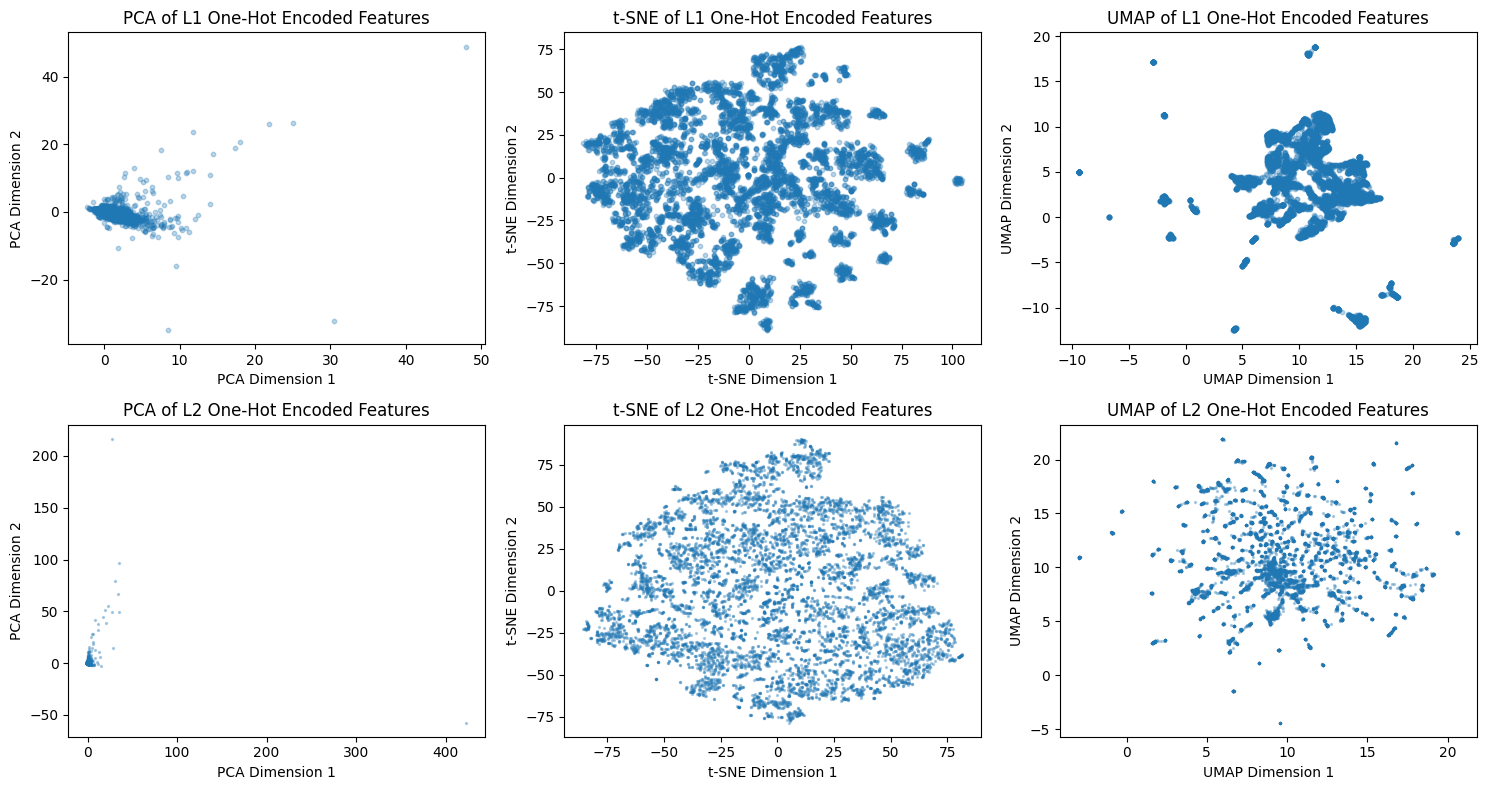

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
# l1_agg
axes[0][0].scatter(X_l1_agg_pca[:, 0], X_l1_agg_pca[:, 1], alpha=0.3, s=10)
axes[0][0].set_title("PCA of L1 One-Hot Encoded Features")
axes[0][0].set_xlabel("PCA Dimension 1")
axes[0][0].set_ylabel("PCA Dimension 2")

axes[0][1].scatter(X_l1_agg_tsne[:, 0], X_l1_agg_tsne[:, 1], alpha=0.3, s=10)
axes[0][1].set_title("t-SNE of L1 One-Hot Encoded Features")
axes[0][1].set_xlabel("t-SNE Dimension 1")
axes[0][1].set_ylabel("t-SNE Dimension 2")

axes[0][2].scatter(X_l1_agg_umap[:, 0], X_l1_agg_umap[:, 1], alpha=0.3, s=10)
axes[0][2].set_title("UMAP of L1 One-Hot Encoded Features")
axes[0][2].set_xlabel("UMAP Dimension 1")
axes[0][2].set_ylabel("UMAP Dimension 2")

# l2_agg
axes[1][0].scatter(X_l2_agg_pca[:, 0], X_l2_agg_pca[:, 1], alpha=0.3, s=2)
axes[1][0].set_title("PCA of L2 One-Hot Encoded Features")
axes[1][0].set_xlabel("PCA Dimension 1")
axes[1][0].set_ylabel("PCA Dimension 2")

axes[1][1].scatter(X_l2_agg_tsne[:, 0], X_l2_agg_tsne[:, 1], alpha=0.3, s=2)
axes[1][1].set_title("t-SNE of L2 One-Hot Encoded Features")
axes[1][1].set_xlabel("t-SNE Dimension 1")
axes[1][1].set_ylabel("t-SNE Dimension 2")

axes[1][2].scatter(X_l2_agg_umap[:, 0], X_l2_agg_umap[:, 1], alpha=0.3, s=2)
axes[1][2].set_title("UMAP of L2 One-Hot Encoded Features")
axes[1][2].set_xlabel("UMAP Dimension 1")
axes[1][2].set_ylabel("UMAP Dimension 2")

plt.tight_layout()
plt.show()

In [9]:
l1_bin_unique_mask = ~l1_bin.drop(columns=["session_id"]).duplicated()
l2_bin_unique_mask = ~l2_bin.drop(columns=["session_id"]).duplicated()

l1_bin_unique = l1_bin.loc[l1_bin_unique_mask].copy()
l2_bin_unique = l2_bin.loc[l2_bin_unique_mask].copy()

X_l1_bin = l1_bin_unique.drop(columns=["session_id"]).astype(float)
X_l2_bin = l2_bin_unique.drop(columns=["session_id"]).astype(float)

X_l1_bin.shape, X_l2_bin.shape

((2420, 51), (7001, 580))

In [10]:
%%time
# l1_bin
truncated_svd_l1_bin = TruncatedSVD(n_components=20, random_state=42)
X_l1_bin_svd = truncated_svd_l1_bin.fit_transform(X_l1_bin)

tsne_l1_bin = TSNE(n_components=2, perplexity=31, metric="cosine", init="random", learning_rate="auto", random_state=42)
X_l1_bin_tsne = tsne_l1_bin.fit_transform(X_l1_bin_svd)

umap_l1_bin = UMAP(n_components=2, n_neighbors=30, min_dist=0.05, metric="cosine", random_state=42)
X_l1_bin_umap = umap_l1_bin.fit_transform(X_l1_bin)

# l2_bin
truncated_svd_l2_bin = TruncatedSVD(n_components=20, random_state=42)
X_l2_bin_svd = truncated_svd_l2_bin.fit_transform(X_l2_bin)

tsne_l2_bin = TSNE(n_components=2, perplexity=31, metric="cosine", init="random", learning_rate="auto", random_state=42)
X_l2_bin_tsne = tsne_l2_bin.fit_transform(X_l2_bin_svd)

umap_l2_bin = UMAP(n_components=2, n_neighbors=30, min_dist=0.05, metric="cosine", random_state=42)
X_l2_bin_umap = umap_l2_bin.fit_transform(X_l2_bin)

/Users/ernestodavidserizeportela/Workspace/google-ecom-emb/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/ernestodavidserizeportela/Workspace/google-ecom-emb/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


CPU times: user 2min 21s, sys: 40.5 s, total: 3min 2s
Wall time: 36.9 s


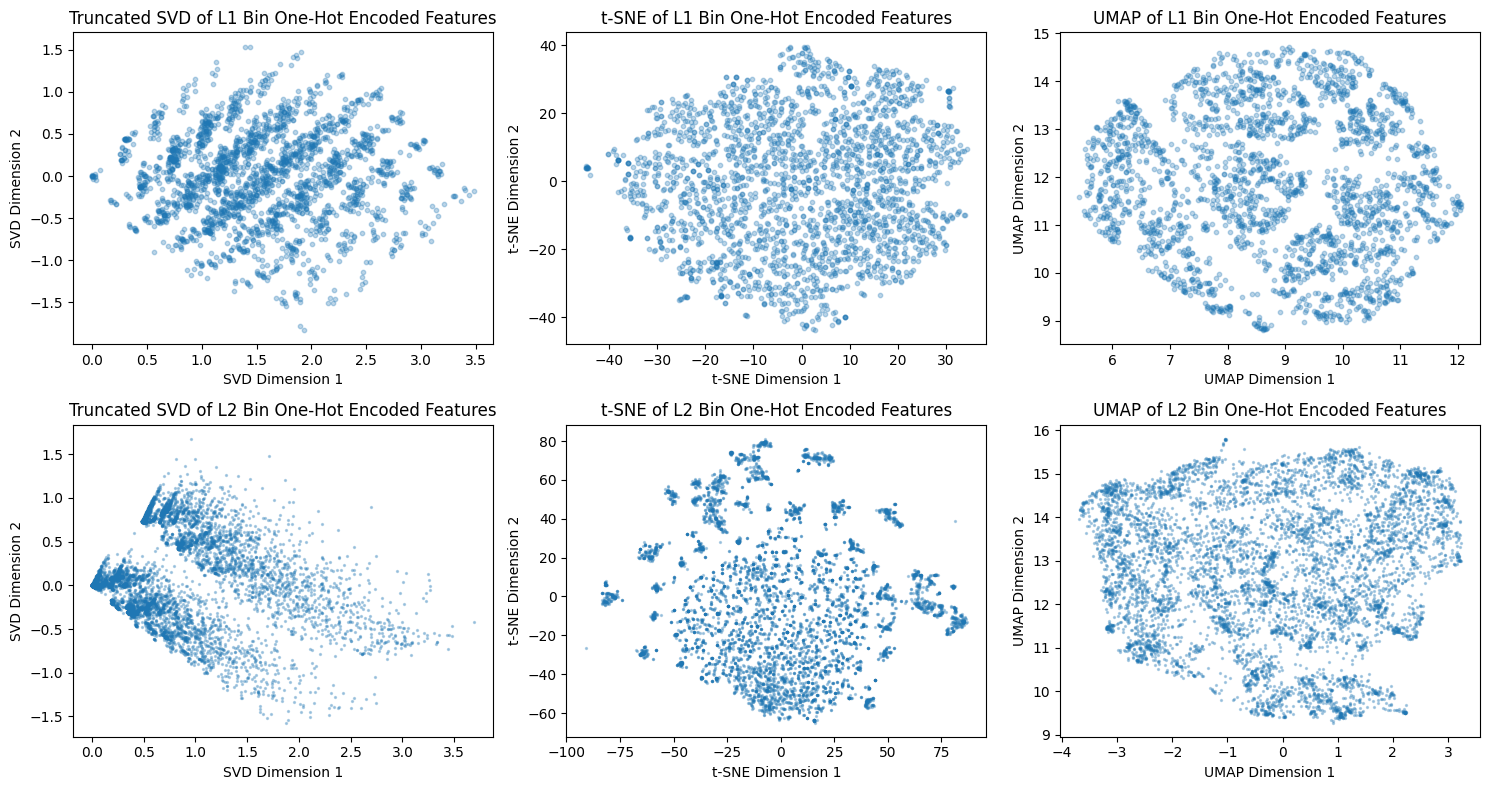

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
# l1_bin
axes[0][0].scatter(X_l1_bin_svd[:, 0], X_l1_bin_svd[:, 1], alpha=0.3, s=10)
axes[0][0].set_title("Truncated SVD of L1 Bin One-Hot Encoded Features")
axes[0][0].set_xlabel("SVD Dimension 1")
axes[0][0].set_ylabel("SVD Dimension 2")

axes[0][1].scatter(X_l1_bin_tsne[:, 0], X_l1_bin_tsne[:, 1], alpha=0.3, s=10)
axes[0][1].set_title("t-SNE of L1 Bin One-Hot Encoded Features")
axes[0][1].set_xlabel("t-SNE Dimension 1")
axes[0][1].set_ylabel("t-SNE Dimension 2")

axes[0][2].scatter(X_l1_bin_umap[:, 0], X_l1_bin_umap[:, 1], alpha=0.3, s=10)
axes[0][2].set_title("UMAP of L1 Bin One-Hot Encoded Features")
axes[0][2].set_xlabel("UMAP Dimension 1")
axes[0][2].set_ylabel("UMAP Dimension 2")

# l2_bin
axes[1][0].scatter(X_l2_bin_svd[:, 0], X_l2_bin_svd[:, 1], alpha=0.3, s=2)
axes[1][0].set_title("Truncated SVD of L2 Bin One-Hot Encoded Features")
axes[1][0].set_xlabel("SVD Dimension 1")
axes[1][0].set_ylabel("SVD Dimension 2")

axes[1][1].scatter(X_l2_bin_tsne[:, 0], X_l2_bin_tsne[:, 1], alpha=0.3, s=2)
axes[1][1].set_title("t-SNE of L2 Bin One-Hot Encoded Features")
axes[1][1].set_xlabel("t-SNE Dimension 1")
axes[1][1].set_ylabel("t-SNE Dimension 2")

axes[1][2].scatter(X_l2_bin_umap[:, 0], X_l2_bin_umap[:, 1], alpha=0.3, s=2)
axes[1][2].set_title("UMAP of L2 Bin One-Hot Encoded Features")
axes[1][2].set_xlabel("UMAP Dimension 1")
axes[1][2].set_ylabel("UMAP Dimension 2")
plt.tight_layout()
plt.show()

In [12]:
session_bin = l1_bin.merge(l2_bin, on="session_id", how="outer").fillna(0)
session_bin_unique_mask = ~session_bin.drop(columns=["session_id"]).duplicated()
session_bin_unique = session_bin.loc[session_bin_unique_mask].copy()
X_combined_bin = session_bin_unique.drop(columns=["session_id"]).astype(float)
X_combined_bin.shape

(10039, 631)

In [13]:
%%time
svd_combined_bin = TruncatedSVD(n_components=50, random_state=42)
X_combined_bin_svd = svd_combined_bin.fit_transform(X_combined_bin)

tsne_combined_bin = TSNE(n_components=2, perplexity=31, metric="cosine", init="random", learning_rate="auto", random_state=42)
X_combined_bin_tsne = tsne_combined_bin.fit_transform(X_combined_bin_svd)

umap_combined_bin = UMAP(n_components=2, n_neighbors=30, min_dist=0.05, metric="cosine", random_state=42,)
X_combined_bin_umap = umap_combined_bin.fit_transform(X_combined_bin)

/Users/ernestodavidserizeportela/Workspace/google-ecom-emb/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


CPU times: user 2min 8s, sys: 39.2 s, total: 2min 47s
Wall time: 25.7 s


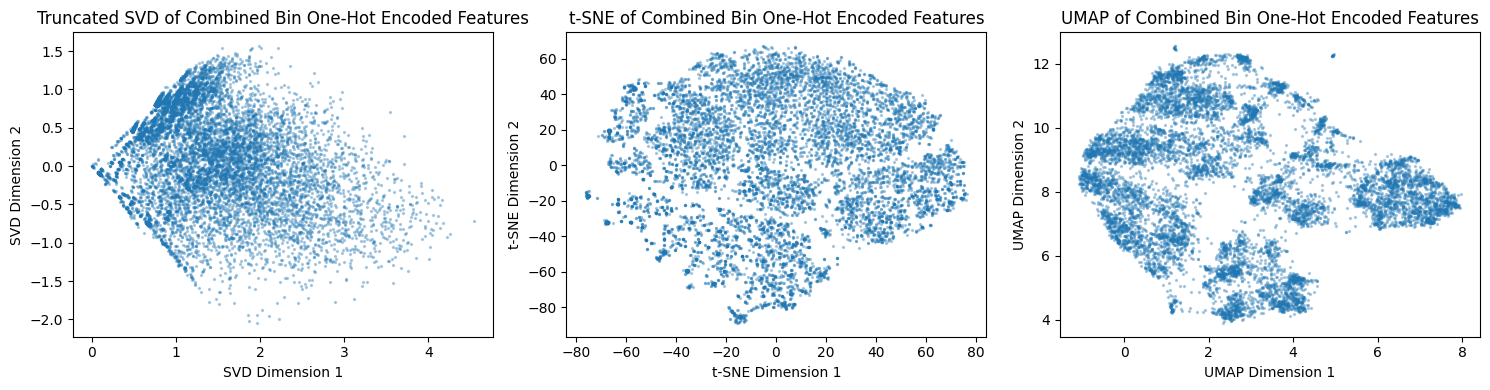

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(X_combined_bin_svd[:, 0], X_combined_bin_svd[:, 1], alpha=0.3, s=2)
axes[0].set_title("Truncated SVD of Combined Bin One-Hot Encoded Features")
axes[0].set_xlabel("SVD Dimension 1")
axes[0].set_ylabel("SVD Dimension 2")

axes[1].scatter(X_combined_bin_tsne[:, 0], X_combined_bin_tsne[:, 1], alpha=0.3, s=2)
axes[1].set_title("t-SNE of Combined Bin One-Hot Encoded Features")
axes[1].set_xlabel("t-SNE Dimension 1")
axes[1].set_ylabel("t-SNE Dimension 2")

axes[2].scatter(X_combined_bin_umap[:, 0], X_combined_bin_umap[:, 1], alpha=0.3, s=2)
axes[2].set_title("UMAP of Combined Bin One-Hot Encoded Features")
axes[2].set_xlabel("UMAP Dimension 1")
axes[2].set_ylabel("UMAP Dimension 2")

plt.tight_layout()
plt.show()

In [15]:
# clustering with HDBSCAN on the 2d UMAP for l1_bin
# select hyperparameters
results = []

for min_cluster_size in [20, 30, 40, 50, 75, 100, 150]:
    for min_samples in [5, 10, 15, 20, 30]:
        clusterer = hdbscan.HDBSCAN(
            min_cluster_size=min_cluster_size,
            min_samples=min_samples,
            metric="euclidean",
            cluster_selection_method="eom",
            prediction_data=True,
        )

        labels = clusterer.fit_predict(X_l1_bin_umap)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise_ratio = np.mean(labels == -1)
        mask = labels != -1

        if n_clusters >= 2 and mask.sum() > 1:
            silhouette = silhouette_score(X_l1_bin_umap[mask], labels[mask])
            davies_bouldin = davies_bouldin_score(X_l1_bin_umap[mask], labels[mask])
            calinski_harabasz = calinski_harabasz_score(X_l1_bin_umap[mask], labels[mask])
            mean_probability = clusterer.probabilities_[mask].mean()
            mean_persistence = clusterer.cluster_persistence_.mean()
        else:
            silhouette = np.nan
            davies_bouldin = np.nan
            calinski_harabasz = np.nan
            mean_probability = np.nan
            mean_persistence = np.nan

        results.append({
            "min_cluster_size": min_cluster_size,
            "min_samples": min_samples,
            "n_clusters": n_clusters,
            "noise_ratio": noise_ratio,
            "silhouette": silhouette,
            "davies_bouldin": davies_bouldin,
            "calinski_harabasz": calinski_harabasz,
            "mean_probability": mean_probability,
            "mean_persistence": mean_persistence,
        })

hdbscan_search_df = pd.DataFrame(results)

hdbscan_search_df.sort_values(
    ["silhouette", "mean_persistence", "noise_ratio"],
    ascending=[False, False, True]
)

,min_cluster_size,min_samples,n_clusters,noise_ratio,silhouette,davies_bouldin,calinski_harabasz,mean_probability,mean_persistence
2,20,15,17,0.273554,0.439321,0.581732,1429.993288,0.960712,0.113717
4,20,30,10,0.380165,0.437965,0.604980,1014.299413,0.960631,0.094001
22,75,15,6,0.169835,0.421441,0.730213,1805.566119,0.969997,0.115586
15,50,5,13,0.178099,0.419456,0.829787,2332.978720,0.937951,0.186320
20,75,5,13,0.178099,0.419456,0.829787,2332.978720,0.957567,0.166603
29,100,30,3,0.188843,0.416406,0.900665,1682.237956,0.945117,0.120170
34,150,30,3,0.188843,0.416406,0.900665,1682.237956,0.962494,0.116207
24,75,30,3,0.188843,0.416406,0.900665,1682.237956,0.959008,0.099496
14,40,30,3,0.188843,0.416406,0.900665,1682.237956,0.992453,0.069909
26,100,10,6,0.121488,0.413830,0.746135,1930.898717,0.966284,0.140735


In [16]:
# 100	10	6	0.121488	0.413830	0.746135	1930.898717	0.966284	0.140735
hdbscan_umap = hdbscan.HDBSCAN(
    min_cluster_size=100,
    min_samples=10,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True,
)
l1_umap_labels = hdbscan_umap.fit_predict(X_l1_bin_umap)

In [17]:
session_plot_metadata = (
    ecom_df_filtered
    .groupby(["user_id", "session_id"])
    .agg(session_start=("timestamp", "min"))
    .reset_index()
    .sort_values(["user_id", "session_start", "session_id"])
)
session_plot_metadata["session_order"] = session_plot_metadata.groupby("user_id").cumcount() + 1
session_plot_metadata["n_clustered_sessions"] = session_plot_metadata.groupby("user_id")["session_id"].transform("size")

l1_umap_plot_df = pd.DataFrame({
    "session_id": l1_bin_unique["session_id"].to_numpy(),
    "umap_1": X_l1_bin_umap[:, 0],
    "umap_2": X_l1_bin_umap[:, 1],
    "cluster": l1_umap_labels,
})

l1_umap_plot_df = l1_umap_plot_df.merge(
    session_plot_metadata[["user_id", "session_id", "session_order", "n_clustered_sessions"]],
    on="session_id",
    how="left",
)

fig = px.scatter(
    l1_umap_plot_df,
    x="umap_1",
    y="umap_2",
    color=l1_umap_plot_df["cluster"].astype(str),
    hover_data=["user_id", "session_id", "session_order", "n_clustered_sessions"],
    opacity=0.55,
    title="Session clusters in L1 UMAP space",
)
fig.update_traces(marker=dict(size=5))
fig.update_layout(width=900, height=650, legend_title_text="cluster")
fig.show()

In [18]:
# build cluster profile dataframe: one row per cluster
# columns: cluster, n_patterns, avg_probability, mean for each L1 category
l1_bin_clustered = l1_bin_unique.copy()
l1_bin_clustered["cluster"] = l1_umap_labels
l1_bin_clustered["cluster_probability"] = hdbscan_umap.probabilities_

l1_feature_cols = [col for col in l1_bin_clustered.columns if col.startswith("l1_")]
cluster_profile_df = (
    l1_bin_clustered
    .groupby("cluster")
    .agg(
        n_patterns=("cluster", "size"),
        avg_probability=("cluster_probability", "mean"),
        **{
            col: (col, "mean")
            for col in l1_feature_cols
        }
    )
    .reset_index()
    .sort_values("cluster")
    .reset_index(drop=True)
)

In [19]:
# choose features with enough signal
threshold = 0.25
plot_feature_cols = [
    col for col in cluster_profile_df.columns
    if col.startswith("l1_") and cluster_profile_df[col].max() >= threshold
]
plot_feature_labels = [col.replace("l1_", "") for col in plot_feature_cols]
# optional: exclude noise cluster
plot_df = cluster_profile_df.query("cluster != -1").sort_values("cluster").reset_index(drop=True)


fig = go.Figure()
for _, row in plot_df.iterrows():
    cluster_id = int(row["cluster"])
    values = row[plot_feature_cols].to_numpy(dtype=float)
    values_closed = np.append(values, values[0])
    labels_closed = plot_feature_labels + [plot_feature_labels[0]]

    fig.add_trace(
        go.Scatterpolar(
            r=values_closed,
            theta=labels_closed,
            fill="toself",
            name=(
                f"cluster {cluster_id} "
                f"| n={int(row['n_patterns'])} "
                f"| p={row['avg_probability']:.2f}"
            ),
            opacity=0.55,
        )
    )

fig.update_layout(
    title="L1 Mean Feature Presence by Cluster",
    polar=dict(
        radialaxis=dict(
            visible=True,
            range=[0, 1],
            showticklabels=False,
        )
    ),
    showlegend=True,
    width=950,
    height=550,
)

fig.show()

In [20]:
# clustering with HDBSCAN on the 2d UMAP for combined l1_bin and l2_bin
# select hyperparameters
results = []

for min_cluster_size in [20, 30, 40, 50, 75, 100, 150]:
    for min_samples in [5, 10, 15, 20, 30]:
        clusterer = hdbscan.HDBSCAN(
            min_cluster_size=min_cluster_size,
            min_samples=min_samples,
            metric="euclidean",
            cluster_selection_method="eom",
            prediction_data=True,
        )

        labels = clusterer.fit_predict(X_combined_bin_umap)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise_ratio = np.mean(labels == -1)
        mask = labels != -1

        if n_clusters >= 2 and mask.sum() > 1:
            silhouette = silhouette_score(X_combined_bin_umap[mask], labels[mask])
            davies_bouldin = davies_bouldin_score(X_combined_bin_umap[mask], labels[mask])
            calinski_harabasz = calinski_harabasz_score(X_combined_bin_umap[mask], labels[mask])
            mean_probability = clusterer.probabilities_[mask].mean()
            mean_persistence = clusterer.cluster_persistence_.mean()
        else:
            silhouette = np.nan
            davies_bouldin = np.nan
            calinski_harabasz = np.nan
            mean_probability = np.nan
            mean_persistence = np.nan

        results.append({
            "min_cluster_size": min_cluster_size,
            "min_samples": min_samples,
            "n_clusters": n_clusters,
            "noise_ratio": noise_ratio,
            "silhouette": silhouette,
            "davies_bouldin": davies_bouldin,
            "calinski_harabasz": calinski_harabasz,
            "mean_probability": mean_probability,
            "mean_persistence": mean_persistence,
        })

hdbscan_combined_search_df = pd.DataFrame(results)

hdbscan_combined_search_df.sort_values(
    ["silhouette", "mean_persistence", "noise_ratio"],
    ascending=[False, False, True]
).reset_index(drop=True)

,min_cluster_size,min_samples,n_clusters,noise_ratio,silhouette,davies_bouldin,calinski_harabasz,mean_probability,mean_persistence
0,100,30,18,0.212372,0.512932,0.573353,12511.648514,0.916914,0.199509
1,50,30,26,0.210180,0.482925,0.524698,9721.041347,0.916576,0.138592
2,50,20,26,0.185477,0.472276,0.549022,9967.817352,0.919810,0.150038
3,40,20,26,0.185477,0.472276,0.549022,9967.817352,0.912893,0.147587
4,30,30,27,0.215260,0.471813,0.514714,9369.126788,0.906278,0.141497
5,40,30,27,0.215260,0.471813,0.514714,9369.126788,0.915412,0.139686
6,150,30,13,0.151808,0.470790,0.592083,11470.253441,0.929579,0.192864
7,150,20,13,0.145034,0.460962,0.586553,11147.011482,0.924643,0.205467
8,150,15,12,0.133878,0.455024,0.610112,11755.014657,0.931270,0.218584
9,150,10,13,0.103795,0.449959,0.630765,11454.830998,0.939283,0.203989


In [21]:
# 150	15	12	0.133878	0.455024	0.610112	11755.014657	0.931270	0.218584
hdbscan_combined_umap = hdbscan.HDBSCAN(
    min_cluster_size=150,
    min_samples=15,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True,
)
combined_umap_labels = hdbscan_combined_umap.fit_predict(X_combined_bin_umap)

In [22]:
session_plot_metadata = (
    ecom_df_filtered
    .groupby(["user_id", "session_id"])
    .agg(session_start=("timestamp", "min"))
    .reset_index()
    .sort_values(["user_id", "session_start", "session_id"])
)
session_plot_metadata["session_order"] = session_plot_metadata.groupby("user_id").cumcount() + 1
session_plot_metadata["n_clustered_sessions"] = session_plot_metadata.groupby("user_id")["session_id"].transform("size")

combined_umap_plot_df = pd.DataFrame({
    "session_id": session_bin_unique["session_id"].to_numpy(),
    "umap_1": X_combined_bin_umap[:, 0],
    "umap_2": X_combined_bin_umap[:, 1],
    "cluster": combined_umap_labels,
})

combined_umap_plot_df = combined_umap_plot_df.merge(
    session_plot_metadata[["user_id", "session_id", "session_order", "n_clustered_sessions"]],
    on="session_id",
    how="left",
)

fig = px.scatter(
    combined_umap_plot_df,
    x="umap_1",
    y="umap_2",
    color=combined_umap_plot_df["cluster"].astype(str),
    hover_data=["user_id", "session_id", "session_order", "n_clustered_sessions"],
    opacity=0.55,
    title="Session clusters in combined L1/L2 UMAP space",
)
fig.update_traces(marker=dict(size=5))
fig.update_layout(width=900, height=650, legend_title_text="cluster")
fig.show()

In [23]:

# build cluster profile dataframe: one row per cluster
# columns: cluster, n_patterns, avg_probability, mean for each L1 and L2 category
combined_bin_clustered = X_combined_bin.copy()
combined_bin_clustered["cluster"] = combined_umap_labels
combined_bin_clustered["cluster_probability"] = hdbscan_combined_umap.probabilities_

combined_feature_cols = [
    col for col in combined_bin_clustered.columns
    if col.startswith("l1_") or col.startswith("l2_")
]
combined_cluster_profile_df = (
    combined_bin_clustered
    .groupby("cluster")
    .agg(
        n_patterns=("cluster", "size"),
        avg_probability=("cluster_probability", "mean"),
        **{
            col: (col, "mean")
            for col in combined_feature_cols
        }
    )
    .reset_index()
    .sort_values("cluster")
    .reset_index(drop=True)
)

/var/folders/z2/x55d_0sd3zl143hy_l05bnpr0000gn/T/ipykernel_77350/2945120292.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  .reset_index()


In [24]:
# choose features with enough signal
threshold = 0.25
plot_feature_cols = [
    col for col in combined_cluster_profile_df.columns
    if (col.startswith("l1_") or col.startswith("l2_")) and combined_cluster_profile_df[col].max() >= threshold
]
plot_feature_labels = [
    col.replace("l1_", "L1: ").replace("l2_", "L2: ")
    for col in plot_feature_cols
]
# optional: exclude noise cluster
plot_df = combined_cluster_profile_df.query("cluster != -1").sort_values("cluster").reset_index(drop=True)


fig = go.Figure()
for _, row in plot_df.iterrows():
    cluster_id = int(row["cluster"])
    values = row[plot_feature_cols].to_numpy(dtype=float)
    values_closed = np.append(values, values[0])
    labels_closed = plot_feature_labels + [plot_feature_labels[0]]

    fig.add_trace(
        go.Scatterpolar(
            r=values_closed,
            theta=labels_closed,
            fill="toself",
            name=(
                f"cluster {cluster_id} "
                f"| n={int(row['n_patterns'])} "
                f"| p={row['avg_probability']:.2f}"
            ),
            opacity=0.55,
        )
    )

fig.update_layout(
    title="Combined L1 and L2 Mean Feature Presence by Cluster",
    polar=dict(
        radialaxis=dict(
            visible=True,
            range=[0, 1],
            showticklabels=False,
        )
    ),
    showlegend=True,
    width=950,
    height=550,
)

fig.show()

In [25]:
# save combined l1_bin/l2_bin features with UMAP coordinates and cluster labels
session_combined_l1_l2_full = pd.concat(
    [
        session_bin_unique[["session_id"]].reset_index(drop=True),
        X_combined_bin.reset_index(drop=True),
    ],
    axis=1,
)
session_combined_l1_l2_full["umap_1"] = X_combined_bin_umap[:, 0]
session_combined_l1_l2_full["umap_2"] = X_combined_bin_umap[:, 1]
session_combined_l1_l2_full["cluster"] = combined_umap_labels
session_combined_l1_l2_full["cluster_probability"] = hdbscan_combined_umap.probabilities_

session_users = (
    ecom_df_filtered[["user_id", "session_id"]]
    .drop_duplicates()
    .copy()
)

session_combined_l1_l2_full = (
    session_users
    .merge(session_combined_l1_l2_full, on="session_id", how="inner")
    .sort_values(["user_id", "session_id"])
    .reset_index(drop=True)
)

OUTPUT_PATH = "data/session_combined_l1_l2_max_features_umap_clusters.csv"
session_combined_l1_l2_full.to_csv(OUTPUT_PATH, index=False)